# IV Case Study: EDA, Target Choice, and Leakage Risks

This notebook is intentionally compact and conclusion-driven.
It follows five steps:
1. Data scope and cleaning checks
2. Feature distributions
3. Target-selection analysis (single benchmark)
4. Leakage diagnostics (day-level constancy + random vs chrono)
5. One-page conclusion


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Matplotlib style fallback for older environments
for _style in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot']:
    try:
        plt.style.use(_style)
        break
    except Exception:
        pass

DATA_CANDIDATES = [
    Path('examples/iv/data/kaggle/prepared/options_dataset.csv'),
    Path('data/kaggle/prepared/options_dataset.csv'),
    Path('data/options_dataset.csv'),
    Path('examples/iv/data/options_dataset.csv'),
    Path('../../data/options_dataset.csv'),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find options_dataset.csv in: {[str(x) for x in DATA_CANDIDATES]}"
    )

print('Using dataset:', DATA_PATH.resolve())
df = pd.read_csv(DATA_PATH)
print('Raw shape:', df.shape)
print('Columns:', list(df.columns))


Using dataset: /Users/erikapat/Dropbox/medium-2025/ML_deceptively_easy/examples/iv/data/kaggle/prepared/options_dataset.csv
Raw shape: (2657286, 10)
Columns: ['date', 'option_id', 'iv', 'delta', 'dte', 'spy_ret', 'vix', 'target_diff', 'target_logret', 'option_type']


In [2]:
df.head(100)

,date,option_id,iv,delta,dte,spy_ret,vix,target_diff,target_logret,option_type
0,2010-01-05,SPY_2010-02-19_100.00_C,0.26480,0.735542,45.0,0.003089,1.990284,-0.00470,-0.017594,call
1,2010-01-06,SPY_2010-02-19_100.00_C,0.26858,0.736908,44.0,0.000880,1.990284,0.00378,0.014174,call
2,2010-01-07,SPY_2010-02-19_100.00_C,0.27121,0.743120,43.0,0.004044,1.990284,0.00263,0.009745,call
3,2010-01-08,SPY_2010-02-19_100.00_C,0.26484,0.747634,42.0,0.002977,1.990284,-0.00637,-0.023768,call
4,2010-01-11,SPY_2010-02-19_100.00_C,0.28277,0.750127,39.0,0.001659,1.990284,0.01793,0.065508,call


### Dataset Headline Metrics\n\nQuick summary matching the dashboard-style stats (`rows`, `option_id values`, `trading days`, `date range`, `core fields missing`).\n

In [3]:
# Headline metrics block
m = df.copy()
m['date'] = pd.to_datetime(m['date'], errors='coerce')

rows = int(len(m))
option_ids = int(m['option_id'].nunique()) if 'option_id' in m.columns else 0
trading_days = int(m['date'].dt.normalize().nunique()) if 'date' in m.columns else 0

date_min = m['date'].min()
date_max = m['date'].max()
date_range = (
    f"{date_min.year}–{date_max.year}"
    if pd.notna(date_min) and pd.notna(date_max)
    else 'N/A'
)

core = [c for c in ['date','option_id','iv','delta','dte','spy_ret','vix'] if c in m.columns]
if core:
    core_missing_pct = float(m[core].isna().sum().sum() / (len(m) * len(core)) * 100.0) if len(m) else float('nan')
else:
    core_missing_pct = float('nan')

headline = pd.DataFrame([
    {'metric': 'rows', 'value': f"{rows:,}"},
    {'metric': 'option_id values', 'value': f"{option_ids:,}"},
    {'metric': 'trading days', 'value': f"{trading_days:,}"},
    {'metric': 'date range', 'value': date_range},
    {'metric': 'core fields missing (%)', 'value': f"{core_missing_pct:.2f}%" if pd.notna(core_missing_pct) else 'N/A'},
])
headline


,metric,value
0,rows,"2,657,286"
1,option_id values,"45,018"
2,trading days,"2,251"
3,date range,2010–2018
4,core fields missing (%),0.00%


## 1) Data Scope and Cleaning Checks
Paper-like setup (for IV): calls, DTE > 14, delta in (0.05, 0.95), chronological evaluation.


In [4]:
# Standardize core columns if present
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

for c in ['iv', 'delta', 'dte', 'spy_ret', 'vix', 'target_diff']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Keep rows with valid date + iv for EDA
base = df.copy()
base = base.dropna(subset=[c for c in ['date', 'iv'] if c in base.columns])

# Strict paper-like mask (for diagnostics)
mask = pd.Series(True, index=base.index)
if 'option_type' in base.columns:
    mask &= base['option_type'].astype(str).str.upper().eq('C')
if 'dte' in base.columns:
    mask &= base['dte'] > 14
if 'delta' in base.columns:
    mask &= (base['delta'] > 0.05) & (base['delta'] < 0.95)

paper_like = base[mask].copy()

# If strict filters empty the sample, apply a safe fallback for EDA visibility
# while keeping the issue explicit in the output.
filter_mode = 'paper_like_strict'
if len(paper_like) == 0:
    filter_mode = 'fallback_nonempty'
    fallback_mask = pd.Series(True, index=base.index)
    if 'dte' in base.columns:
        fallback_mask &= base['dte'] > 14
    # Relax delta bounds to inclusive and tolerate tiny numeric noise.
    if 'delta' in base.columns:
        fallback_mask &= (base['delta'] >= 0.049) & (base['delta'] <= 0.951)
    paper_like = base[fallback_mask].copy()
    if len(paper_like) == 0:
        # Last resort: keep all valid rows so notebook can continue.
        filter_mode = 'fallback_base_valid'
        paper_like = base.copy()

scope = {
    'rows_raw': len(df),
    'rows_base_valid_date_iv': len(base),
    'rows_paper_like_filters': len(paper_like),
    'filter_mode_used': filter_mode,
    'start_date': str(base['date'].min()) if 'date' in base.columns and len(base) else None,
    'end_date': str(base['date'].max()) if 'date' in base.columns and len(base) else None,
    'n_days': int(base['date'].dt.normalize().nunique()) if 'date' in base.columns and len(base) else 0,
    'n_options': int(base['option_id'].nunique()) if 'option_id' in base.columns and len(base) else 0,
}
print(pd.Series(scope))

# Missingness report
miss_cols = [c for c in ['iv','delta','dte','spy_ret','vix','target_diff'] if c in base.columns]
miss = pd.DataFrame({
    'column': miss_cols,
    'missing_rate': [float(base[c].isna().mean()) for c in miss_cols]
}).sort_values('missing_rate', ascending=False)
miss

if filter_mode != 'paper_like_strict':
    print(f"Warning: strict paper-like filters produced 0 rows. Using {filter_mode} for EDA plots.")


rows_raw                               2657286
rows_base_valid_date_iv                2657286
rows_paper_like_filters                2657286
filter_mode_used             fallback_nonempty
start_date                 2010-01-05 00:00:00
end_date                   2018-12-31 00:00:00
n_days                                    2251
n_options                                45018
dtype: object


### 1.1) Why This Is Panel Data\n\nA panel dataset has repeated observations of the same entity over time.\nHere, entity = `option_id` and time = `date`.\n

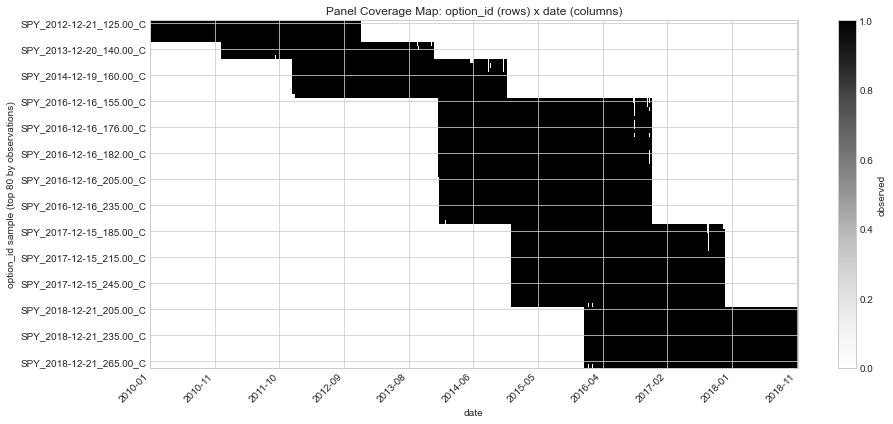

In [5]:
# Panel-data diagnostics: entity-time structure
panel_base = df.copy()
panel_base['date'] = pd.to_datetime(panel_base['date'], errors='coerce')
panel_base = panel_base.dropna(subset=['date', 'option_id'])

n_rows = len(panel_base)
n_entities = panel_base['option_id'].nunique()
n_dates = panel_base['date'].nunique()
rows_per_id = panel_base.groupby('option_id').size()
ids_per_date = panel_base.groupby('date')['option_id'].nunique()

panel_summary = pd.DataFrame([
    {'metric': 'rows', 'value': n_rows},
    {'metric': 'entities (option_id)', 'value': n_entities},
    {'metric': 'dates', 'value': n_dates},
    {'metric': 'avg rows per entity', 'value': float(rows_per_id.mean()) if len(rows_per_id) else np.nan},
    {'metric': 'median rows per entity', 'value': float(rows_per_id.median()) if len(rows_per_id) else np.nan},
    {'metric': 'avg entities per date', 'value': float(ids_per_date.mean()) if len(ids_per_date) else np.nan},
])
panel_summary

# Coverage map: sample of entities x dates (1 if observed)
sample_n = 80
sample_ids = rows_per_id.sort_values(ascending=False).head(sample_n).index
pidx = panel_base[['option_id','date']].drop_duplicates().copy()
mat = (
    pidx[pidx['option_id'].isin(sample_ids)]
    .assign(obs=1)
    .pivot(index='option_id', columns='date', values='obs')
    .fillna(0)
)

plt.figure(figsize=(12, 6))
plt.imshow(mat.values, aspect='auto', interpolation='nearest')
plt.title('Panel Coverage Map: option_id (rows) x date (columns)')
plt.ylabel(f'sample option_id (top {sample_n} by observations)')
plt.colorbar(label='observed')

# fechas reales en el eje x (submuestreadas)
x_dates = pd.to_datetime(mat.columns)
step = max(1, len(x_dates)//10)
ticks = np.arange(0, len(x_dates), step)
labels = [x_dates[i].strftime('%Y-%m') for i in ticks]
plt.xticks(ticks, labels, rotation=45, ha='right')
plt.xlabel('date')
plt.tight_layout()

# Y with option_id labels
y_ids = mat.index.astype(str).tolist()
y_step = max(1, len(y_ids)//12)
y_ticks = np.arange(0, len(y_ids), y_step)
y_labels = [y_ids[i] for i in y_ticks]
plt.yticks(y_ticks, y_labels)
plt.ylabel(f'option_id sample (top {sample_n} by observations)')
plt.show()


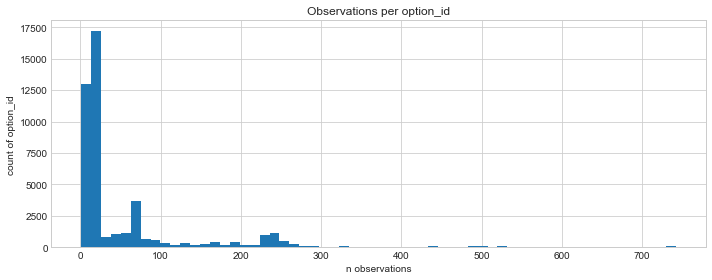

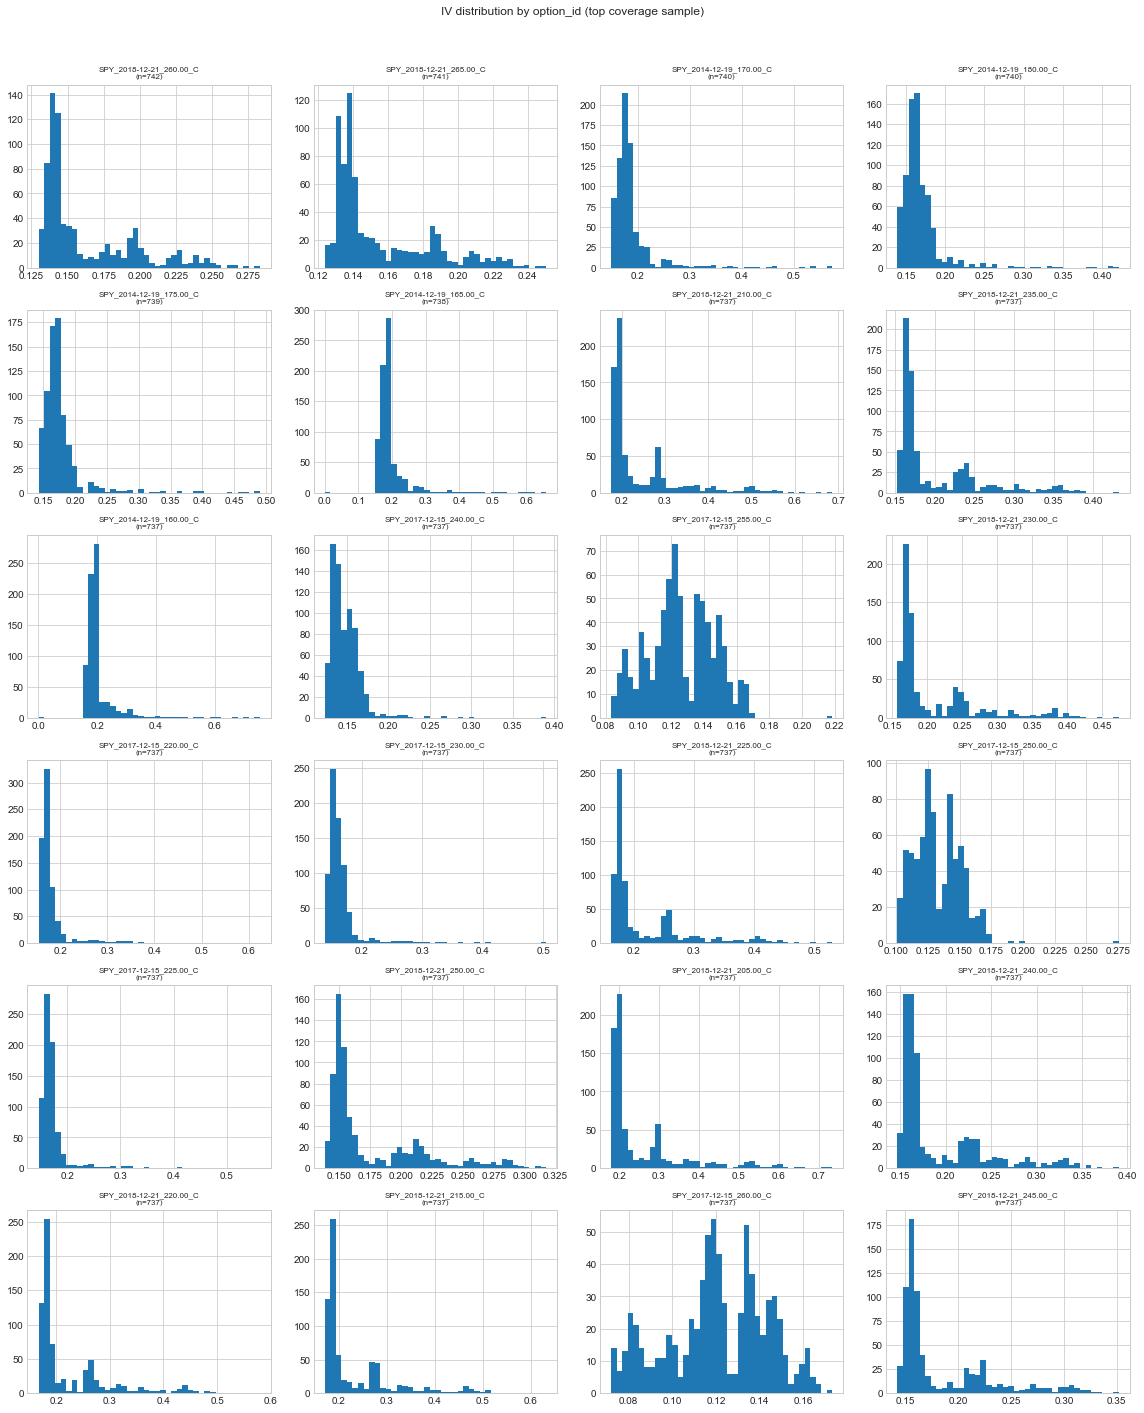

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

w = df.copy()
w["iv"] = pd.to_numeric(w["iv"], errors="coerce")
w = w.dropna(subset=["option_id", "iv"])

# 1) Coverage distribution (how unbalanced panel is)
obs = w.groupby("option_id").size().sort_values(ascending=False)
plt.figure(figsize=(10,4))
plt.hist(obs.values, bins=60)
plt.title("Observations per option_id")
plt.xlabel("n observations")
plt.ylabel("count of option_id")
plt.tight_layout()
plt.show()

# 2) IV histogram per option_id (sample of most represented IDs)
top_n = 24
ids = obs.head(top_n).index.tolist()

ncols = 4
nrows = int(np.ceil(top_n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, oid in enumerate(ids):
    s = w.loc[w["option_id"] == oid, "iv"]
    axes[i].hist(s, bins=40)
    axes[i].set_title(f"{oid}\n(n={len(s)})", fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("IV distribution by option_id (top coverage sample)", y=1.02)
fig.tight_layout()
plt.show()


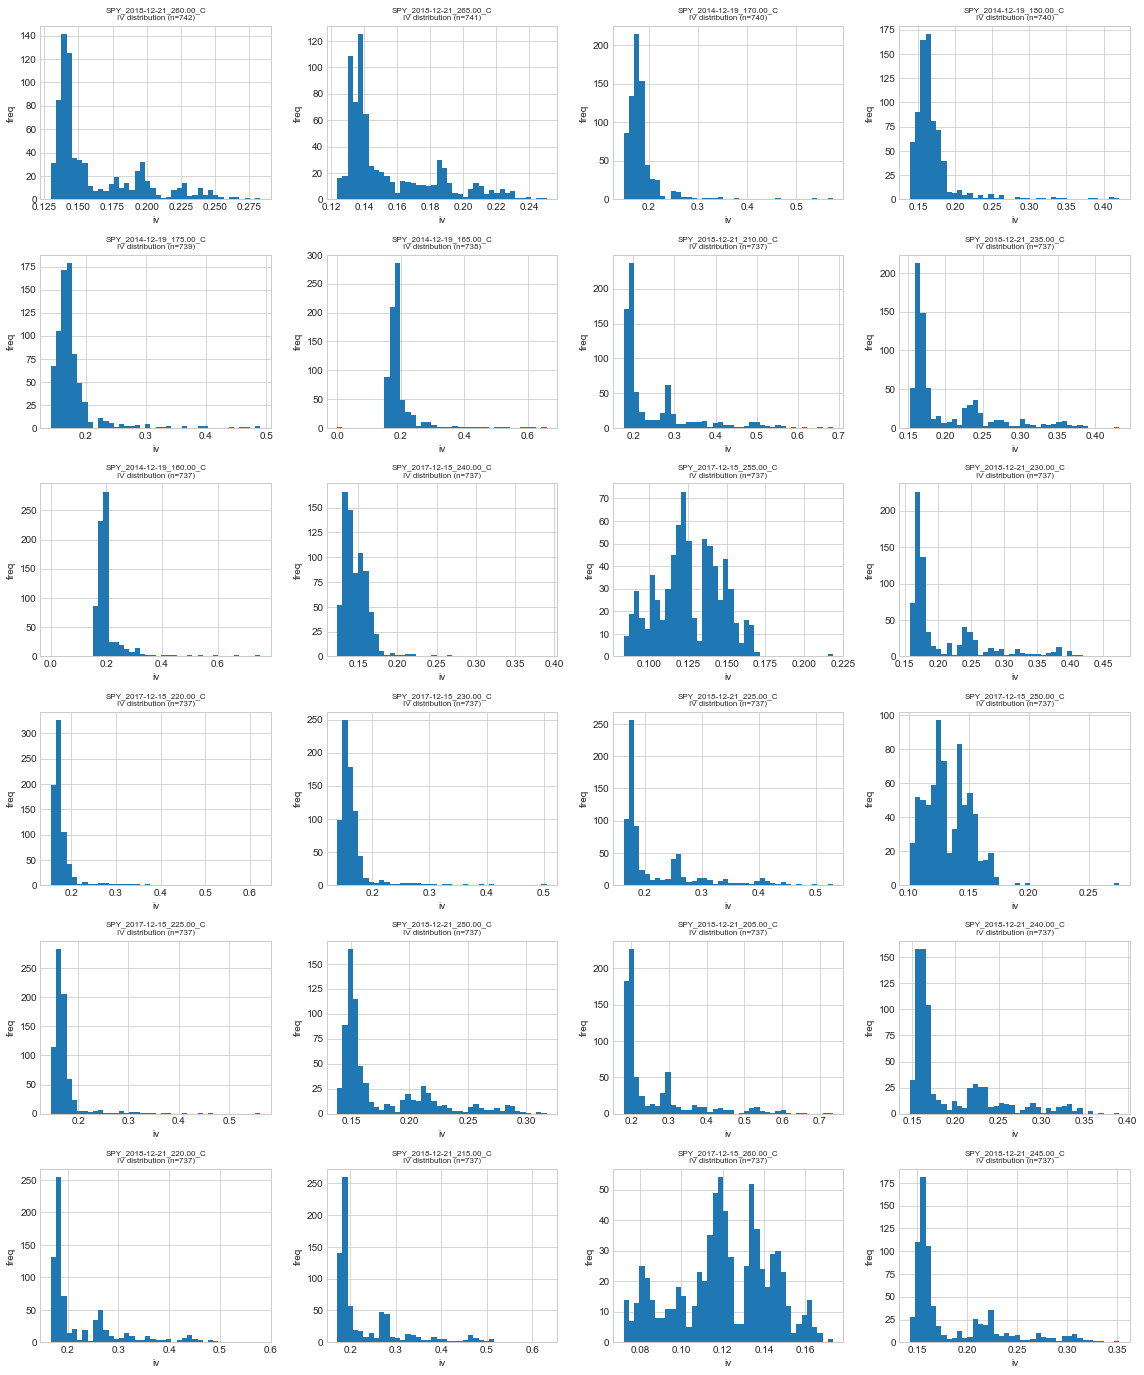

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

w = df.copy()
w["iv"] = pd.to_numeric(w["iv"], errors="coerce")
w = w.dropna(subset=["option_id", "iv"])

# sample de option_id para poder visualizar
top_n = 24
ids = w.groupby("option_id").size().sort_values(ascending=False).head(top_n).index

ncols = 4
nrows = int(np.ceil(len(ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows))
axes = np.array(axes).reshape(-1)

for i, oid in enumerate(ids):
    s = w.loc[w["option_id"] == oid, "iv"]
    axes[i].hist(s, bins=40)
    axes[i].set_title(f"{oid}\nIV distribution (n={len(s)})", fontsize=8)
    axes[i].set_xlabel("iv")
    axes[i].set_ylabel("freq")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [8]:
df.head()

,date,option_id,iv,delta,dte,spy_ret,vix,target_diff,target_logret,option_type
0,2010-01-05,SPY_2010-02-19_100.00_C,0.26480,0.735542,45.0,0.003089,1.990284,-0.00470,-0.017594,call
1,2010-01-06,SPY_2010-02-19_100.00_C,0.26858,0.736908,44.0,0.000880,1.990284,0.00378,0.014174,call
2,2010-01-07,SPY_2010-02-19_100.00_C,0.27121,0.743120,43.0,0.004044,1.990284,0.00263,0.009745,call
3,2010-01-08,SPY_2010-02-19_100.00_C,0.26484,0.747634,42.0,0.002977,1.990284,-0.00637,-0.023768,call
4,2010-01-11,SPY_2010-02-19_100.00_C,0.28277,0.750127,39.0,0.001659,1.990284,0.01793,0.065508,call


## 2) Feature Distributions
Histogram of the independent variables used by the model.


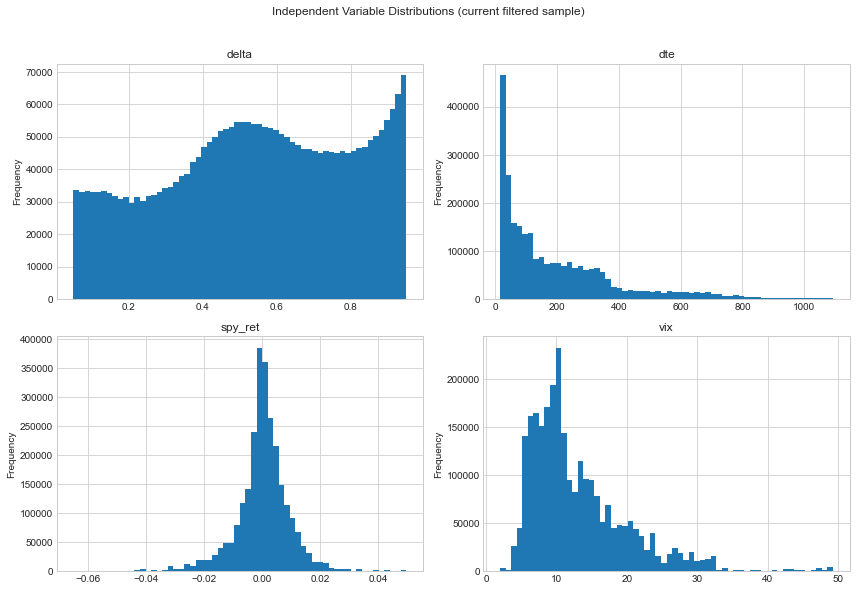

In [9]:
feat_cols = [c for c in ['delta', 'dte', 'spy_ret', 'vix'] if c in paper_like.columns]
if not feat_cols:
    raise ValueError('No model feature columns found in dataset.')

n = len(feat_cols)
rows = 2
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.ravel()

for i, c in enumerate(feat_cols):
    s = pd.to_numeric(paper_like[c], errors='coerce').dropna()
    axes[i].hist(s, bins=60)
    axes[i].set_title(c)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Independent Variable Distributions (current filtered sample)', y=1.02)
fig.tight_layout()
plt.show()


## 3) Target-Selection Analysis (Single Benchmark)
Compare target candidates using one compact workflow.


In [10]:
work = paper_like.copy()
work = work.sort_values(['option_id','date']) if {'option_id','date'}.issubset(work.columns) else work.sort_values('date')

work['iv_level'] = pd.to_numeric(work['iv'], errors='coerce')
if {'option_id','date'}.issubset(work.columns):
    prev_iv = work.groupby('option_id')['iv_level'].shift(1)
else:
    prev_iv = work['iv_level'].shift(1)

work['target_diff'] = work['iv_level'] - prev_iv
with np.errstate(divide='ignore', invalid='ignore'):
    work['target_logret'] = np.log(work['iv_level'] / prev_iv)
work['target_signed_log'] = np.sign(work['target_diff']) * np.log1p(np.abs(work['target_diff']))
work['target_dir'] = (work['target_diff'] > 0).astype(float)

for c in ['iv_level','target_diff','target_logret','target_signed_log']:
    work[c] = pd.to_numeric(work[c], errors='coerce')
    work.loc[~np.isfinite(work[c]), c] = np.nan

work[['iv_level','target_diff','target_logret','target_signed_log','target_dir']].describe().T


,count,mean,std,min,25%,50%,75%,max
iv_level,2657286.0,0.210261,0.104994,-0.000500,0.139940,0.186620,0.248930,1.895230
target_diff,2612268.0,0.001308,0.033808,-1.089150,-0.002720,0.000230,0.003770,1.243930
target_logret,2607831.0,0.003680,0.318233,-11.441956,-0.015216,0.001332,0.020126,11.496959
target_signed_log,2612268.0,0.001267,0.028530,-0.736757,-0.002716,0.000230,0.003763,0.808229
target_dir,2657286.0,0.514267,0.499796,0.000000,0.000000,1.000000,1.000000,1.000000


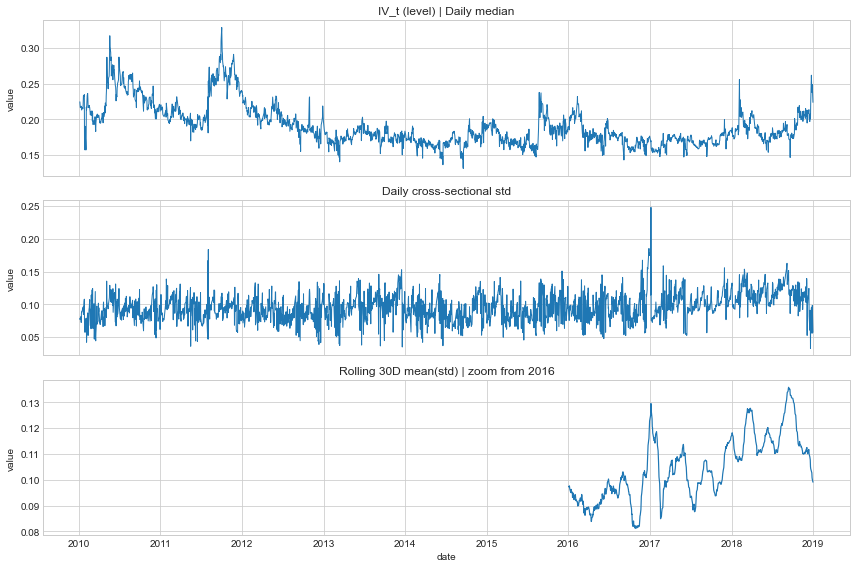

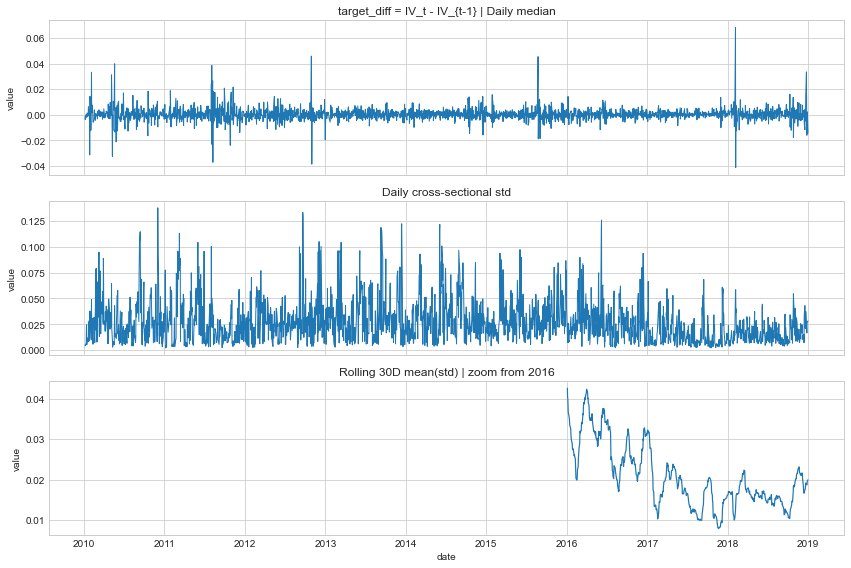

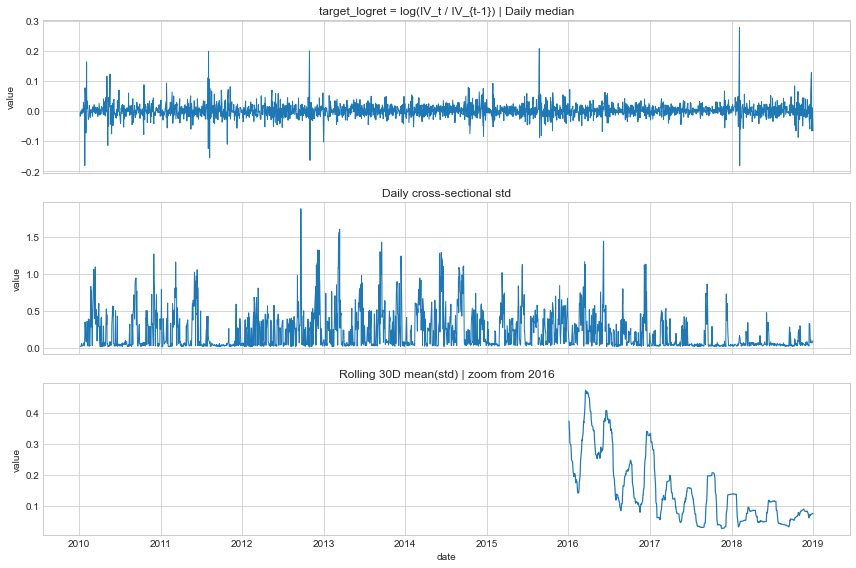

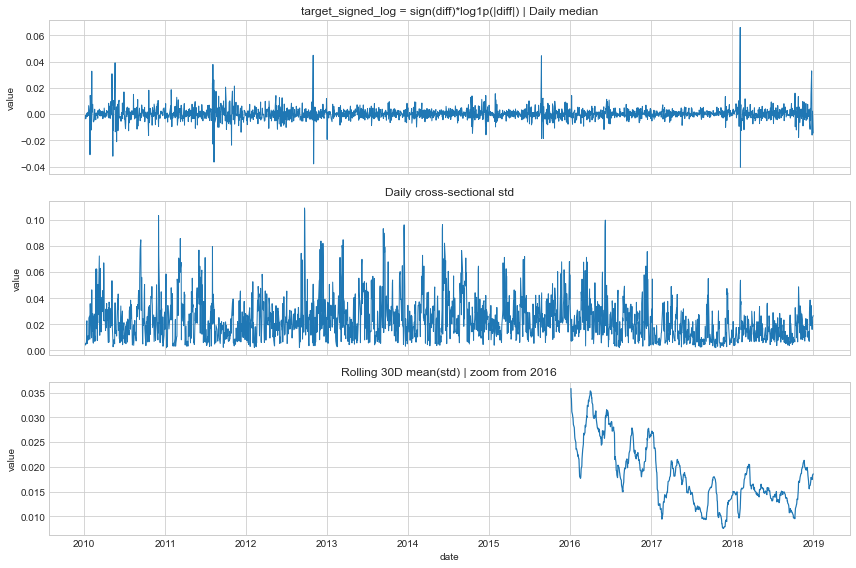

In [11]:
# Plot each target separately (clearer than overlay)
daily = work.groupby('date')[['iv_level','target_diff','target_logret','target_signed_log']].agg(['median','std'])
daily.columns = ['_'.join(c) for c in daily.columns]
daily = daily.dropna().reset_index()

zoom_start = pd.Timestamp('2016-01-01')

targets = [
    ('iv_level', 'IV_t (level)'),
    ('target_diff', 'target_diff = IV_t - IV_{t-1}'),
    ('target_logret', 'target_logret = log(IV_t / IV_{t-1})'),
    ('target_signed_log', 'target_signed_log = sign(diff)*log1p(|diff|)'),
]

for t, title in targets:
    med = f'{t}_median'
    std = f'{t}_std'
    if med not in daily.columns or std not in daily.columns:
        continue

    d = daily[['date', med, std]].dropna().copy()
    d['roll30_mean_std'] = d[std].rolling(30, min_periods=10).mean()

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(d['date'], d[med], linewidth=1.0)
    axes[0].set_title(f'{title} | Daily median')

    axes[1].plot(d['date'], d[std], linewidth=1.0)
    axes[1].set_title('Daily cross-sectional std')

    dz = d[d['date'] >= zoom_start]
    axes[2].plot(dz['date'], dz['roll30_mean_std'], linewidth=1.2)
    axes[2].set_title('Rolling 30D mean(std) | zoom from 2016')

    for ax in axes:
        ax.set_ylabel('value')
    axes[-1].set_xlabel('date')
    fig.tight_layout()
    plt.show()


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

def chrono_split_days(dates, train_frac=0.7, val_frac=0.2):
    uniq = np.array(sorted(pd.to_datetime(dates).dt.normalize().dropna().unique()))
    n = len(uniq)
    i1 = int(n * train_frac)
    i2 = int(n * (train_frac + val_frac))
    dtr, dvl, dte = set(uniq[:i1]), set(uniq[i1:i2]), set(uniq[i2:])
    dd = pd.to_datetime(dates).dt.normalize()
    split = np.where(dd.isin(dtr), 'train', np.where(dd.isin(dvl), 'val', 'test'))
    return split

feature_cols = [c for c in ['spy_ret','delta','dte','vix'] if c in work.columns]
reg_targets = ['iv_level','target_diff','target_logret','target_signed_log']

work['split'] = chrono_split_days(work['date'])

rows = []
for ycol in reg_targets:
    tmp = work[['split','date'] + feature_cols + [ycol]].copy()
    tr = tmp[tmp['split']=='train'].copy()
    te = tmp[tmp['split']=='test'].copy()

    Xtr = tr[feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    ytr = pd.to_numeric(tr[ycol], errors='coerce').to_numpy(dtype=float)
    Xte = te[feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    yte = pd.to_numeric(te[ycol], errors='coerce').to_numpy(dtype=float)

    mask_tr = np.isfinite(Xtr).all(axis=1) & np.isfinite(ytr)
    mask_te = np.isfinite(Xte).all(axis=1) & np.isfinite(yte)
    Xtr, ytr = Xtr[mask_tr], ytr[mask_tr]
    Xte, yte = Xte[mask_te], yte[mask_te]

    if len(ytr) < 100 or len(yte) < 100:
        continue

    m = LinearRegression()
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)

    # Temporal stability stats by day
    z = tmp[['date', ycol]].dropna().copy()
    z['date'] = pd.to_datetime(z['date'])
    g = z.groupby('date')[ycol].agg(['median','std']).dropna()

    rows.append({
        'target': ycol,
        'test_mse': float(mean_squared_error(yte, yp)),
        'test_mae': float(mean_absolute_error(yte, yp)),
        'test_r2': float(r2_score(yte, yp)),
        'direction_acc': float(accuracy_score((yte>0).astype(int), (yp>0).astype(int))) if ycol != 'iv_level' else np.nan,
        'mean_daily_std': float(g['std'].mean()) if len(g) else np.nan,
        'cv_daily_std': float(g['std'].std()/g['std'].mean()) if len(g) and g['std'].mean()!=0 else np.nan,
    })

target_benchmark = pd.DataFrame(rows).sort_values(['test_mse','cv_daily_std'])
target_benchmark


,target,test_mse,test_mae,test_r2,direction_acc,mean_daily_std,cv_daily_std
3,target_signed_log,0.000380,0.008854,-0.003867,0.553490,0.023444,0.695477
1,target_diff,0.000443,0.009071,-0.004015,0.553997,0.027331,0.763067
0,iv_level,0.007487,0.057290,0.474001,NaN,0.095943,0.226555
2,target_logret,0.011597,0.037145,0.006021,0.546801,0.215915,1.215217


## 4) Leakage Diagnostics
Two direct checks:
- Day-level constancy of macro features (`spy_ret`, `vix`)
- Performance inflation under random split vs chronological split


In [13]:
# Day-level constancy
const_rows = []
for c in ['spy_ret','vix']:
    if c not in work.columns:
        continue
    g = work[['date', c]].dropna().groupby('date')[c].nunique()
    const_rows.append({
        'feature': c,
        'pct_days_unique_eq_1': float((g == 1).mean()),
        'median_unique_values_per_day': float(g.median())
    })

constancy = pd.DataFrame(const_rows)
constancy


,feature,pct_days_unique_eq_1,median_unique_values_per_day
0,spy_ret,1.0,1.0
1,vix,1.0,1.0


In [14]:
from sklearn.model_selection import train_test_split

# Random vs chrono on one practical target
ycol = 'target_diff'
cols = [ycol] + feature_cols
tmp = work[['date'] + cols].copy()

X = tmp[feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
y = pd.to_numeric(tmp[ycol], errors='coerce').to_numpy(dtype=float)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X[mask], y[mask]

def eval_lr(Xtr, ytr, Xte, yte):
    m = LinearRegression()
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    return {
        'mse': float(mean_squared_error(yte, p)),
        'mae': float(mean_absolute_error(yte, p)),
        'r2': float(r2_score(yte, p)),
        'direction_acc': float(accuracy_score((yte>0).astype(int), (p>0).astype(int)))
    }

# Chronological split
tmp2 = tmp.loc[mask].copy()
tmp2['split'] = chrono_split_days(tmp2['date'])
tr = tmp2['split'].eq('train').to_numpy()
te = tmp2['split'].eq('test').to_numpy()
chrono_metrics = eval_lr(X[tr], y[tr], X[te], y[te])

# Random split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
random_metrics = eval_lr(Xtr, ytr, Xte, yte)

split_compare = pd.DataFrame([
    {'split': 'chronological', **chrono_metrics},
    {'split': 'random', **random_metrics}
])
split_compare


,split,mse,mae,r2,direction_acc
0,chronological,0.000443,0.009071,-0.004020,0.553957
1,random,0.001110,0.009102,0.006169,0.585462


## 5) One-Page Conclusion
Use this block as a draft for the article narrative.


In [15]:
best_target = target_benchmark.iloc[0]['target'] if len(target_benchmark) else 'N/A'

print('Conclusion draft:')
print(f'- Data was analyzed under paper-like filters; exact values may differ from the paper due to source differences.')
print(f'- Most stable/predictable target in this dataset snapshot: {best_target}.')

if len(constancy):
    for _, r in constancy.iterrows():
        print(f"- {r['feature']}: days with exactly one value across all contracts = {100*r['pct_days_unique_eq_1']:.1f}% (leakage risk if random split).")

if len(split_compare)==2:
    c = split_compare.loc[split_compare['split']=='chronological'].iloc[0]
    r = split_compare.loc[split_compare['split']=='random'].iloc[0]
    print(f"- Random vs chronological (target_diff): MSE {r['mse']:.6f} vs {c['mse']:.6f}, R2 {r['r2']:.4f} vs {c['r2']:.4f}.")
    print('- If random looks better, treat it as optimistic due to temporal/panel leakage.')

print('- Recommendation: report chronological OOS metrics as primary; keep random split only as leakage stress test.')


Conclusion draft:
- Data was analyzed under paper-like filters; exact values may differ from the paper due to source differences.
- Most stable/predictable target in this dataset snapshot: target_signed_log.
- spy_ret: days with exactly one value across all contracts = 100.0% (leakage risk if random split).
- vix: days with exactly one value across all contracts = 100.0% (leakage risk if random split).
- Random vs chronological (target_diff): MSE 0.001110 vs 0.000443, R2 0.0062 vs -0.0040.
- If random looks better, treat it as optimistic due to temporal/panel leakage.
- Recommendation: report chronological OOS metrics as primary; keep random split only as leakage stress test.


## Appendix: IV Distribution Summary by `option_id`\n\nThis table quantifies heterogeneity of IV distributions across contracts (coverage-bias diagnostics).\n

In [16]:
w = df.copy()
w['iv'] = pd.to_numeric(w['iv'], errors='coerce')
w = w.dropna(subset=['option_id','iv'])

grp = w.groupby('option_id')['iv']
summary = grp.agg(n_obs='size', mean='mean', std='std', min='min', max='max', median='median')
summary['iqr'] = grp.quantile(0.75) - grp.quantile(0.25)
summary['skew'] = grp.skew()
summary['kurtosis'] = grp.apply(pd.Series.kurt)
summary['cv'] = summary['std'] / summary['mean'].replace(0, np.nan)

# keep only contracts with enough history for stable moments
min_obs = 30
summary_f = summary[summary['n_obs'] >= min_obs].copy()

print(f'Contracts total: {summary.shape[0]}')
print(f'Contracts with n_obs >= {min_obs}: {summary_f.shape[0]}')

# Distribution of distribution-shape metrics across contracts
metric_cols = ['std','iqr','skew','kurtosis','cv']
summary_over_contracts = summary_f[metric_cols].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).T
summary_over_contracts


Contracts total: 45018
Contracts with n_obs >= 30: 14622


,count,mean,std,min,10%,25%,50%,75%,90%,max
std,14622.0,0.047231,0.039839,0.002835,0.010032,0.016248,0.033568,0.066922,0.106690,0.255841
iqr,14622.0,0.046234,0.040914,0.001775,0.010561,0.016747,0.031800,0.063535,0.103623,0.347810
skew,14622.0,1.060628,1.320688,-9.428255,-0.351901,0.302794,1.090597,1.855702,2.581780,10.027135
kurtosis,14622.0,3.961979,6.294999,-1.840640,-0.652635,0.193215,2.069286,5.389078,10.386978,119.812973
cv,14622.0,0.187292,0.105367,0.009883,0.066365,0.100908,0.166680,0.259909,0.340273,0.645381


In [17]:
# Contracts with most dispersed IV distributions
summary_f.sort_values('std', ascending=False).head(20)


,n_obs,mean,std,min,max,median,iqr,skew,kurtosis,cv
option_id,,,,,,,,,,
SPY_2017-01-20_187.00_C,71,0.396418,0.255841,-0.00029,1.20960,0.267820,0.212755,1.386897,1.339691,0.645381
SPY_2017-01-20_183.00_C,68,0.415079,0.252944,-0.00015,1.28998,0.283645,0.220413,1.460629,1.571801,0.609388
SPY_2010-06-30_78.00_C,37,0.547758,0.246081,-0.00019,1.13002,0.417930,0.328930,0.036129,0.074238,0.449252
SPY_2017-01-20_184.00_C,69,0.418846,0.245043,0.20962,1.27519,0.289380,0.230330,1.485293,1.517022,0.585043
SPY_2012-06-15_93.00_C,31,0.523625,0.236956,0.36863,1.06139,0.395770,0.193310,1.390511,0.257847,0.452530
SPY_2017-01-20_188.00_C,69,0.378096,0.236070,0.00018,1.17316,0.259540,0.202590,1.353275,1.313904,0.624366
SPY_2017-01-20_186.00_C,69,0.405126,0.236002,0.21028,1.22972,0.279190,0.218950,1.491019,1.515686,0.582541
SPY_2011-04-15_92.00_C,51,0.487517,0.230697,-0.00025,1.07426,0.476290,0.183375,-0.019272,1.342379,0.473207
SPY_2011-08-19_92.00_C,34,0.547668,0.227666,-0.00048,1.20982,0.481680,0.154210,1.162093,3.079778,0.415701


## Appendix: XGBoost Prediction Distributions (With vs Without Leakage)\n\n- **With leakage**: random row split.\n- **Without leakage**: chronological day split.\n- We plot prediction distributions separately for **train** and **test**.\n

,setup,split,mse,r2
0,random_with_leakage,train,0.000977,0.138346
1,random_with_leakage,test,0.001031,0.106250
2,chrono_without_leakage,train,0.001205,0.151396
3,chrono_without_leakage,test,0.000472,0.000292


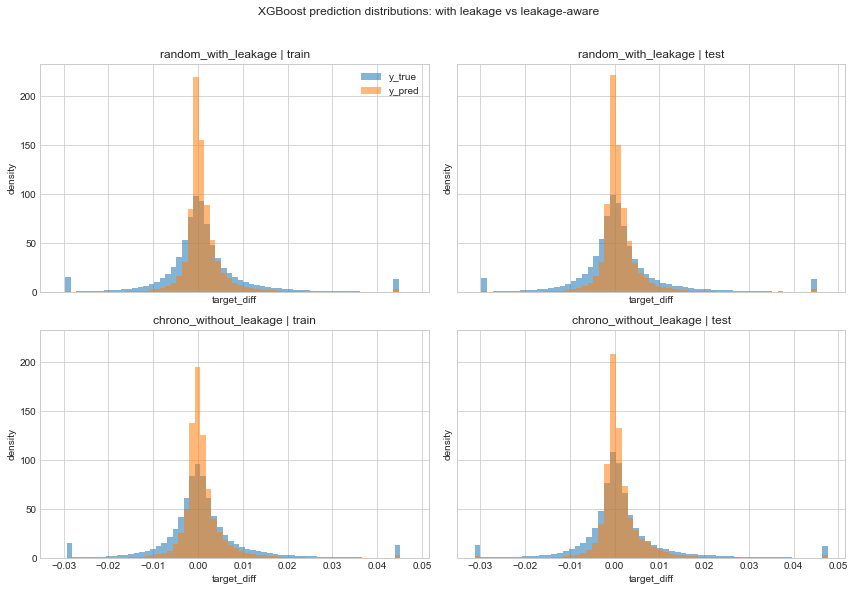

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print('XGBoost not available:', e)

if not HAS_XGB:
    print('Install/fix xgboost to run this section.')
else:
    xgb_df = df.copy()
    xgb_df['date'] = pd.to_datetime(xgb_df['date'], errors='coerce')

    # Use prepared target if available, else compute from iv+option_id
    if 'target_diff' not in xgb_df.columns:
        if {'iv','option_id'}.issubset(xgb_df.columns):
            xgb_df['iv'] = pd.to_numeric(xgb_df['iv'], errors='coerce')
            xgb_df = xgb_df.sort_values(['option_id','date'])
            xgb_df['target_diff'] = xgb_df.groupby('option_id')['iv'].diff()
        else:
            raise ValueError('Need target_diff or iv+option_id.')

    feat_cols = [c for c in ['spy_ret','delta','dte','vix'] if c in xgb_df.columns]
    for c in feat_cols + ['target_diff']:
        xgb_df[c] = pd.to_numeric(xgb_df[c], errors='coerce')

    xgb_df = xgb_df.dropna(subset=['date'] + feat_cols + ['target_diff']).reset_index(drop=True)

    X = xgb_df[feat_cols].to_numpy(dtype=float)
    y = xgb_df['target_diff'].to_numpy(dtype=float)

    # ---------- split A: random row-wise (leakage-prone) ----------
    rng = np.random.default_rng(42)
    idx = np.arange(len(xgb_df))
    rng.shuffle(idx)
    n_tr = int(0.8 * len(idx))
    tr_r, te_r = idx[:n_tr], idx[n_tr:]

    # ---------- split B: chronological day-wise (leakage-aware) ----------
    day = xgb_df['date'].dt.strftime('%Y-%m-%d')
    uniq = np.array(sorted(day.unique()))
    n_day_tr = int(0.8 * len(uniq))
    dtr = set(uniq[:n_day_tr])
    tr_c = np.where(day.isin(dtr))[0]
    te_c = np.where(~day.isin(dtr))[0]

    def fit_and_predict(tr_idx, te_idx, label):
        m = XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=4,
        )
        m.fit(X[tr_idx], y[tr_idx])
        p_tr = m.predict(X[tr_idx])
        p_te = m.predict(X[te_idx])
        return {
            'label': label,
            'y_tr': y[tr_idx],
            'p_tr': p_tr,
            'y_te': y[te_idx],
            'p_te': p_te,
            'mse_tr': float(np.mean((y[tr_idx]-p_tr)**2)),
            'mse_te': float(np.mean((y[te_idx]-p_te)**2)),
            'r2_tr': float(1 - np.sum((y[tr_idx]-p_tr)**2)/np.sum((y[tr_idx]-y[tr_idx].mean())**2)),
            'r2_te': float(1 - np.sum((y[te_idx]-p_te)**2)/np.sum((y[te_idx]-y[te_idx].mean())**2)),
        }

    res_random = fit_and_predict(tr_r, te_r, 'random_with_leakage')
    res_chrono = fit_and_predict(tr_c, te_c, 'chrono_without_leakage')

    metrics = pd.DataFrame([
        {'setup':res_random['label'],'split':'train','mse':res_random['mse_tr'],'r2':res_random['r2_tr']},
        {'setup':res_random['label'],'split':'test','mse':res_random['mse_te'],'r2':res_random['r2_te']},
        {'setup':res_chrono['label'],'split':'train','mse':res_chrono['mse_tr'],'r2':res_chrono['r2_tr']},
        {'setup':res_chrono['label'],'split':'test','mse':res_chrono['mse_te'],'r2':res_chrono['r2_te']},
    ])
    display(metrics)

    # Distributions: y_true vs y_pred for each setup and split
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

    configs = [
        (res_random, 'train', axes[0,0]),
        (res_random, 'test',  axes[0,1]),
        (res_chrono, 'train', axes[1,0]),
        (res_chrono, 'test',  axes[1,1]),
    ]

    for r, split_name, ax in configs:
        yt = r['y_tr'] if split_name=='train' else r['y_te']
        yp = r['p_tr'] if split_name=='train' else r['p_te']

        lo = np.nanpercentile(np.concatenate([yt, yp]), 1)
        hi = np.nanpercentile(np.concatenate([yt, yp]), 99)
        yt_c = np.clip(yt, lo, hi)
        yp_c = np.clip(yp, lo, hi)

        ax.hist(yt_c, bins=60, alpha=0.55, label='y_true', density=True)
        ax.hist(yp_c, bins=60, alpha=0.55, label='y_pred', density=True)
        ax.set_title(f"{r['label']} | {split_name}")
        ax.set_xlabel('target_diff')
        ax.set_ylabel('density')

    axes[0,0].legend(loc='upper right')
    fig.suptitle('XGBoost prediction distributions: with leakage vs leakage-aware', y=1.02)
    fig.tight_layout()
    plt.show()


## Appendix: Correlation Matrix of Main Variables


,iv,delta,dte,spy_ret,vix,target_diff,target_logret
iv,1.000000,0.625465,-0.142377,-0.028124,0.181807,0.218150,0.114768
delta,0.625465,1.000000,-0.086418,0.024902,-0.103656,0.027000,0.000980
dte,-0.142377,-0.086418,1.000000,0.001632,-0.013663,-0.034237,-0.008113
spy_ret,-0.028124,0.024902,0.001632,1.000000,0.003077,-0.076904,-0.046082
vix,0.181807,-0.103656,-0.013663,0.003077,1.000000,-0.012703,-0.004893
target_diff,0.218150,0.027000,-0.034237,-0.076904,-0.012703,1.000000,0.765833
target_logret,0.114768,0.000980,-0.008113,-0.046082,-0.004893,0.765833,1.000000


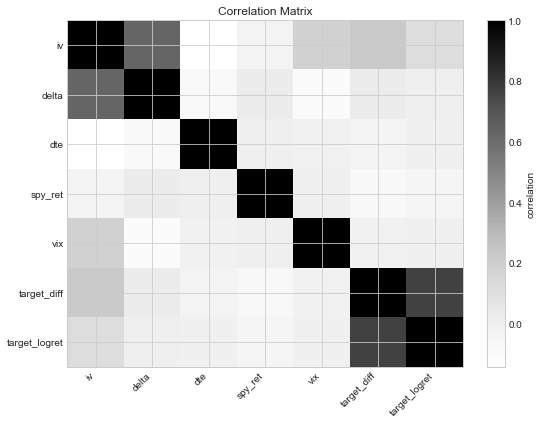

In [19]:
corr_cols = [c for c in ['iv','delta','dte','spy_ret','vix','target_diff','target_logret'] if c in df.columns]
cd = df[corr_cols].copy()
for c in corr_cols:
    cd[c] = pd.to_numeric(cd[c], errors='coerce')
cd = cd.dropna()

try:
    corr = cd.corr(numeric_only=True)
except TypeError:
    corr = cd.corr()
display(corr)

plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect='auto', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label='correlation')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


## Leakage Overlap Diagnostics (Same-Day / Same-Contract)

These metrics quantify structural leakage risk under random row split versus chronological split.


In [20]:
# Leakage overlap diagnostics
lz = df.copy()
lz['date'] = pd.to_datetime(lz['date'], errors='coerce')
lz = lz.dropna(subset=['date']).reset_index(drop=True)

idx = np.arange(len(lz))

# Random split (row-wise)
rng = np.random.default_rng(42)
rng.shuffle(idx)
n_tr = int(0.8 * len(idx))
tr_r, te_r = idx[:n_tr], idx[n_tr:]

# Chronological split (day-wise)
days = lz['date'].dt.strftime('%Y-%m-%d')
uniq = np.array(sorted(days.unique()))
n_day_tr = int(0.8 * len(uniq))
d_train = set(uniq[:n_day_tr])
tr_c = np.where(days.isin(d_train))[0]
te_c = np.where(~days.isin(d_train))[0]

def overlap_metrics(df_in, tr_idx, te_idx):
    tr = df_in.iloc[tr_idx]
    te = df_in.iloc[te_idx]

    tr_days = set(tr['date'].dt.strftime('%Y-%m-%d'))
    te_days = set(te['date'].dt.strftime('%Y-%m-%d'))
    overlap_days = tr_days & te_days

    out = {
        'n_train_rows': int(len(tr)),
        'n_test_rows': int(len(te)),
        'n_train_days': int(len(tr_days)),
        'n_test_days': int(len(te_days)),
        'n_overlap_days': int(len(overlap_days)),
        'pct_test_rows_on_overlap_days': float(te['date'].dt.strftime('%Y-%m-%d').isin(overlap_days).mean()) if len(te) else np.nan,
    }

    if 'option_id' in df_in.columns:
        tr_ids = set(tr['option_id'].dropna().astype(str))
        te_ids = set(te['option_id'].dropna().astype(str))
        overlap_ids = tr_ids & te_ids
        out['n_train_option_id'] = int(len(tr_ids))
        out['n_test_option_id'] = int(len(te_ids))
        out['n_overlap_option_id'] = int(len(overlap_ids))
        out['pct_test_rows_on_overlap_option_id'] = float(te['option_id'].astype(str).isin(overlap_ids).mean()) if len(te) else np.nan

    return out

m_random = overlap_metrics(lz, tr_r, te_r)
m_chrono = overlap_metrics(lz, tr_c, te_c)

overlap_tbl = pd.DataFrame([
    {'split': 'random_rowwise', **m_random},
    {'split': 'chronological_daywise', **m_chrono},
])
overlap_tbl


,split,n_train_rows,n_test_rows,n_train_days,n_test_days,n_overlap_days,pct_test_rows_on_overlap_days,n_train_option_id,n_test_option_id,n_overlap_option_id,pct_test_rows_on_overlap_option_id
0,random_rowwise,2125828,531458,2251,2251,2251,1.0,44800,41340,41122,0.999496
1,chronological_daywise,1865374,791912,1800,451,0,0.0,27377,19065,1424,0.212419


**Interpretation:** High overlap in random split means train/test share same days or same contracts, which can inflate apparent OOS performance.


## XGBoost Prediction Quality Metrics (Random vs Chronological)

This table reports **XGBoost** prediction quality (MSE, MAE, R2, direction accuracy) for train/test under both splits.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import numpy as np
import pandas as pd

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise RuntimeError(
        f"XGBoost is required for this cell and is not available in the current kernel: {e}"
    )

q = df.copy()
q['date'] = pd.to_datetime(q['date'], errors='coerce')

feat = [c for c in ['spy_ret','delta','dte','vix'] if c in q.columns]
ycol = 'target_diff'  # change to target_logret if needed

X = q[feat].apply(pd.to_numeric, errors='coerce').to_numpy(float)
y = pd.to_numeric(q[ycol], errors='coerce').to_numpy(float)
d = q['date']

mask = np.isfinite(X).all(axis=1) & np.isfinite(y) & d.notna().to_numpy()
X, y, d = X[mask], y[mask], d[mask]

def metrics(y_true, y_pred):
    return {
        'mse': float(mean_squared_error(y_true, y_pred)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'direction_acc': float(accuracy_score((y_true > 0).astype(int), (y_pred > 0).astype(int))),
    }

rows = []

def fit_xgb(Xtr, ytr):
    m = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=4,
    )
    m.fit(Xtr, ytr)
    return m

# RANDOM split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
m = fit_xgb(Xtr, ytr)
ptr, pte = m.predict(Xtr), m.predict(Xte)
rows += [
    {'setup': 'random', 'split': 'train', **metrics(ytr, ptr)},
    {'setup': 'random', 'split': 'test',  **metrics(yte, pte)},
]

# CHRONO split (day-wise)
day = pd.to_datetime(d).dt.strftime('%Y-%m-%d')
ud = np.array(sorted(day.unique()))
dtr = set(ud[:int(0.8 * len(ud))])
tr = day.isin(dtr).to_numpy()
te = ~tr

m2 = fit_xgb(X[tr], y[tr])
ptr2, pte2 = m2.predict(X[tr]), m2.predict(X[te])
rows += [
    {'setup': 'chrono', 'split': 'train', **metrics(y[tr], ptr2)},
    {'setup': 'chrono', 'split': 'test',  **metrics(y[te], pte2)},
]

quality_tbl_xgb = pd.DataFrame(rows)
quality_tbl_xgb


,setup,split,mse,mae,r2,direction_acc
0,random,train,0.000986,0.007759,0.139236,0.677169
1,random,test,0.000986,0.007755,0.106958,0.677416
2,chrono,train,0.001205,0.008202,0.151396,0.689906
3,chrono,test,0.000472,0.007956,0.000292,0.562969



## Mean Reversion Test (Coverage-Aware)

Core question:

\[
\Delta IV_{t+1} = lpha + eta\,dev_t + arepsilon_{t+1}
\]

where \(dev_t = IV_t - 	ext{past rolling center}_t\). Evidence of mean reversion is \(eta < 0\).

Important implementation choices:
- **Past-only rolling windows** (no centered windows, no future leakage).
- **Coverage-aware estimation** because panel coverage is unbalanced across `option_id`.
  - We report pooled estimates.
  - We also report a filtered sample (`min_obs_per_option`) and option-balanced weights (`1 / n_obs(option_id)`).


In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

work_mr = df.copy()
work_mr['date'] = pd.to_datetime(work_mr['date'])
work_mr = work_mr.sort_values(['option_id', 'date']).reset_index(drop=True)

# Keep only needed columns
cols_needed = ['option_id', 'date', 'iv']
missing_cols = [c for c in cols_needed if c not in work_mr.columns]
if missing_cols:
    raise ValueError(f"Missing columns for mean-reversion analysis: {missing_cols}")

# Panel coverage diagnostics
obs_per_option = work_mr.groupby('option_id').size().rename('n_obs')
coverage_stats = obs_per_option.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame('value')
coverage_stats


,value
count,45018.000000
mean,59.027189
std,95.842308
min,1.000000
10%,6.000000
25%,13.000000
50%,19.000000
75%,66.000000
90%,209.000000
max,742.000000


In [23]:

# Build past-only rolling centers and next-day IV change
window = 20

# Past-only center: shift(1) ensures no look-ahead
g = work_mr.groupby('option_id')['iv']
work_mr['iv_center_mean_20'] = g.transform(lambda s: s.shift(1).rolling(window, min_periods=10).mean())
work_mr['iv_center_median_20'] = g.transform(lambda s: s.shift(1).rolling(window, min_periods=10).median())

# Deviations
work_mr['dev_mean_20'] = work_mr['iv'] - work_mr['iv_center_mean_20']
work_mr['dev_median_20'] = work_mr['iv'] - work_mr['iv_center_median_20']

# Next move target: Delta IV_{t+1}
work_mr['iv_next'] = g.shift(-1)
work_mr['delta_iv_next'] = work_mr['iv_next'] - work_mr['iv']

mr = work_mr.dropna(subset=['dev_mean_20', 'dev_median_20', 'delta_iv_next']).copy()

# Coverage controls
mr = mr.merge(obs_per_option.to_frame(), left_on='option_id', right_index=True, how='left')
mr['w_option_balanced'] = 1.0 / mr['n_obs'].clip(lower=1)

print('Rows in mean-reversion sample:', len(mr))
print('Unique option_id:', mr['option_id'].nunique())
mr[['dev_mean_20','dev_median_20','delta_iv_next']].describe().T


Rows in mean-reversion sample: 2208738
Unique option_id: 35068


,count,mean,std,min,25%,50%,75%,max
dev_mean_20,2208738.0,0.008297,0.032600,-0.737191,-0.002994,0.00216,0.011185,0.755548
dev_median_20,2208738.0,0.008795,0.033486,-0.721415,-0.002720,0.00225,0.011560,0.740990
delta_iv_next,2208738.0,0.001278,0.034247,-1.089150,-0.002590,0.00023,0.003610,1.243930


In [24]:

# Simple weighted OLS helper for y = a + b*x

def wls_alpha_beta(x, y, w=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if w is None:
        w = np.ones_like(x)
    else:
        w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]
    if len(x) < 5:
        return np.nan, np.nan, 0

    X = np.column_stack([np.ones(len(x)), x])
    WX = X * w[:, None]
    beta = np.linalg.lstsq(WX.T @ X, WX.T @ y, rcond=None)[0]
    return float(beta[0]), float(beta[1]), int(len(x))

rows = []
min_obs_threshold = 60

for dev_col in ['dev_mean_20', 'dev_median_20']:
    # 1) pooled, unweighted
    a, b, n = wls_alpha_beta(mr[dev_col], mr['delta_iv_next'])
    rows.append({'spec':'pooled_unweighted', 'dev':dev_col, 'alpha':a, 'beta':b, 'n':n})

    # 2) pooled, option-balanced weights
    a, b, n = wls_alpha_beta(mr[dev_col], mr['delta_iv_next'], mr['w_option_balanced'])
    rows.append({'spec':'pooled_option_balanced', 'dev':dev_col, 'alpha':a, 'beta':b, 'n':n})

    # 3) filtered by coverage + option-balanced
    sub = mr[mr['n_obs'] >= min_obs_threshold]
    a, b, n = wls_alpha_beta(sub[dev_col], sub['delta_iv_next'], sub['w_option_balanced'])
    rows.append({'spec':f'filtered_nobs>={min_obs_threshold}_option_balanced', 'dev':dev_col, 'alpha':a, 'beta':b, 'n':n})

mr_beta = pd.DataFrame(rows)
mr_beta


,spec,dev,alpha,beta,n
0,pooled_unweighted,dev_mean_20,0.004898,-0.436298,2208738
1,pooled_option_balanced,dev_mean_20,0.008454,-0.471769,2208738
2,filtered_nobs>=60_option_balanced,dev_mean_20,0.006089,-0.493287,1973618
3,pooled_unweighted,dev_median_20,0.004905,-0.412346,2208738
4,pooled_option_balanced,dev_median_20,0.008469,-0.442907,2208738
5,filtered_nobs>=60_option_balanced,dev_median_20,0.006115,-0.470371,1973618



Interpretation guide:
- Mean reversion support: **beta < 0** consistently across specs.
- Coverage concern check: if beta flips sign when moving from unweighted to option-balanced/filtered, then results are coverage-driven.


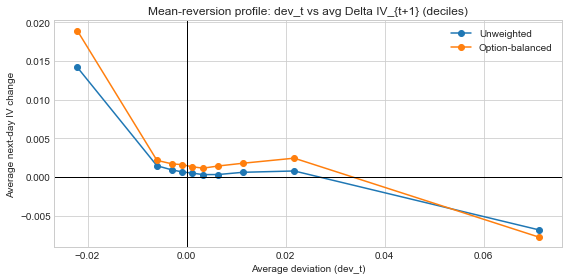

In [25]:

# Visual check: binned relation dev_t -> E[Delta IV_{t+1}]
plot_col = 'dev_mean_20'
sub = mr[[plot_col, 'delta_iv_next', 'w_option_balanced']].dropna().copy()
sub['decile'] = pd.qcut(sub[plot_col], 10, labels=False, duplicates='drop')

bin_stats = sub.groupby('decile').agg(
    dev_mean=(plot_col, 'mean'),
    delta_mean=('delta_iv_next', 'mean'),
    delta_wmean=('delta_iv_next', lambda z: np.average(z, weights=sub.loc[z.index, 'w_option_balanced']))
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bin_stats['dev_mean'], bin_stats['delta_mean'], marker='o', label='Unweighted')
ax.plot(bin_stats['dev_mean'], bin_stats['delta_wmean'], marker='o', label='Option-balanced')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Mean-reversion profile: dev_t vs avg Delta IV_{t+1} (deciles)')
ax.set_xlabel('Average deviation (dev_t)')
ax.set_ylabel('Average next-day IV change')
ax.legend()
plt.tight_layout()
plt.show()



## Feature Importance and Evaluation Metrics

This block adds a compact, reproducible benchmark using the IV feature set:
- Features: `delta`, `dte`, `spy_ret`, `vix`
- Target: `target_diff`
- Split protocols: `random` and `chronological day-wise`
- Metrics: `mse`, `mae`, `r2`, `direction_acc`, `weighted_acc`

If `xgboost` is unavailable, it falls back to `RandomForestRegressor`.


In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split

# Data prep
fx = ['delta', 'dte', 'spy_ret', 'vix']
target_col = 'target_diff'

miss = [c for c in (fx + [target_col, 'date']) if c not in df.columns]
if miss:
    raise ValueError(f"Missing required columns for evaluation block: {miss}")

tmp_eval = df[fx + [target_col, 'date']].copy()
tmp_eval['date'] = pd.to_datetime(tmp_eval['date'])
for c in fx + [target_col]:
    tmp_eval[c] = pd.to_numeric(tmp_eval[c], errors='coerce')
tmp_eval = tmp_eval.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

X = tmp_eval[fx].to_numpy(dtype=float)
y = tmp_eval[target_col].to_numpy(dtype=float)

# Model choice
model_name = None
try:
    from xgboost import XGBRegressor
    def make_model(seed=42):
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=seed,
            n_jobs=4,
        )
    model_name = 'XGBoost'
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    def make_model(seed=42):
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=seed,
            n_jobs=-1,
        )
    model_name = 'RandomForest (fallback)'


def weighted_acc(y_true, y_pred):
    w = np.abs(y_true)
    yt = (y_true > 0).astype(int)
    yp = (y_pred > 0).astype(int)
    if np.sum(w) == 0:
        return float(np.mean(yt == yp))
    return float(np.sum((yt == yp) * w) / np.sum(w))


def eval_rows(y_true, y_pred, setup, split):
    return {
        'setup': setup,
        'split': split,
        'mse': float(mean_squared_error(y_true, y_pred)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'direction_acc': float(accuracy_score((y_true > 0).astype(int), (y_pred > 0).astype(int))),
        'weighted_acc': weighted_acc(y_true, y_pred),
    }

rows = []

# A) RANDOM split: train/val/test = 0.7/0.2/0.1
X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.10, random_state=42, shuffle=True)
X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=(0.20/0.90), random_state=42, shuffle=True)

m = make_model(42)
m.fit(X_tr, y_tr)

rows.append(eval_rows(y_tr, m.predict(X_tr), 'random', 'train'))
rows.append(eval_rows(y_va, m.predict(X_va), 'random', 'val'))
rows.append(eval_rows(y_te, m.predict(X_te), 'random', 'test'))

# B) CHRONO day-wise split: by unique days
days = np.sort(tmp_eval['date'].dt.strftime('%Y-%m-%d').unique())
n_days = len(days)
d_tr = set(days[: int(0.70 * n_days)])
d_va = set(days[int(0.70 * n_days): int(0.90 * n_days)])
d_te = set(days[int(0.90 * n_days):])

mask_tr = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_tr).to_numpy()
mask_va = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_va).to_numpy()
mask_te = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_te).to_numpy()

X_tr_c, y_tr_c = X[mask_tr], y[mask_tr]
X_va_c, y_va_c = X[mask_va], y[mask_va]
X_te_c, y_te_c = X[mask_te], y[mask_te]

m_c = make_model(43)
m_c.fit(X_tr_c, y_tr_c)

rows.append(eval_rows(y_tr_c, m_c.predict(X_tr_c), 'chrono', 'train'))
rows.append(eval_rows(y_va_c, m_c.predict(X_va_c), 'chrono', 'val'))
rows.append(eval_rows(y_te_c, m_c.predict(X_te_c), 'chrono', 'test'))

metrics_tbl = pd.DataFrame(rows)
metrics_tbl = metrics_tbl.sort_values(['setup', 'split']).reset_index(drop=True)
print('Model used for this block:', model_name)
metrics_tbl


Model used for this block: XGBoost


,setup,split,mse,mae,r2,direction_acc,weighted_acc
0,chrono,test,0.000462,0.008961,-0.032385,0.584000,0.621600
1,chrono,train,0.001390,0.008926,0.078462,0.668806,0.721004
2,chrono,val,0.000772,0.007905,-0.039592,0.546753,0.595932
3,random,test,0.001018,0.008158,0.061756,0.642211,0.694354
4,random,train,0.001075,0.008258,0.069073,0.641913,0.694287
5,random,val,0.001038,0.008212,0.059263,0.642228,0.690154


,feature,importance
2,spy_ret,0.340250
1,dte,0.252370
0,delta,0.219598
3,vix,0.187782


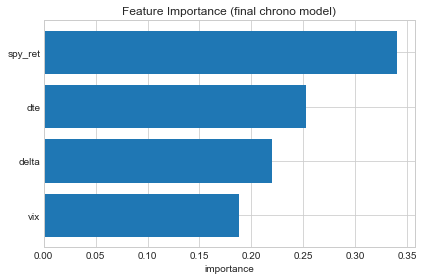

,setup,split,mse,mae,r2,direction_acc,weighted_acc
0,chrono_final_refit_train+val,test,0.000432,0.008611,0.034648,0.596011,0.643535


In [27]:

# Train final chrono model on train+val and plot feature importance
# (this mirrors time-aware practice: tune/inspect on past, evaluate on latest test)

fx = ['delta', 'dte', 'spy_ret', 'vix']

# rebuild chrono masks from existing tmp_eval
days = np.sort(tmp_eval['date'].dt.strftime('%Y-%m-%d').unique())
n_days = len(days)
d_tr = set(days[: int(0.70 * n_days)])
d_va = set(days[int(0.70 * n_days): int(0.90 * n_days)])
d_te = set(days[int(0.90 * n_days):])

mask_tr = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_tr).to_numpy()
mask_va = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_va).to_numpy()
mask_te = tmp_eval['date'].dt.strftime('%Y-%m-%d').isin(d_te).to_numpy()

X_all = tmp_eval[fx].to_numpy(dtype=float)
y_all = tmp_eval[target_col].to_numpy(dtype=float)

mask_trva = mask_tr | mask_va
final_model = make_model(123)
final_model.fit(X_all[mask_trva], y_all[mask_trva])

if hasattr(final_model, 'feature_importances_'):
    imp = pd.DataFrame({'feature': fx, 'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)
    display(imp)

    plt.figure(figsize=(6,4))
    plt.barh(imp['feature'][::-1], imp['importance'][::-1])
    plt.title('Feature Importance (final chrono model)')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()
else:
    print('This model does not expose feature_importances_.')

# Final out-of-sample test metrics (chrono, train+val -> test)
y_pred_test = final_model.predict(X_all[mask_te])
final_test_metrics = {
    'setup': 'chrono_final_refit_train+val',
    'split': 'test',
    'mse': float(mean_squared_error(y_all[mask_te], y_pred_test)),
    'mae': float(mean_absolute_error(y_all[mask_te], y_pred_test)),
    'r2': float(r2_score(y_all[mask_te], y_pred_test)),
    'direction_acc': float(accuracy_score((y_all[mask_te] > 0).astype(int), (y_pred_test > 0).astype(int))),
    'weighted_acc': float(np.sum(((y_all[mask_te] > 0).astype(int) == (y_pred_test > 0).astype(int)) * np.abs(y_all[mask_te])) / np.sum(np.abs(y_all[mask_te]))),
}
pd.DataFrame([final_test_metrics])



## Mean Reversion (Simple Version)

This is a minimal intuition check (no complex panel controls):

1. Build one daily series: median IV across options each day.
2. Build a past-only center (20-day rolling mean).
3. Define:
- `dev_t = IV_t - rolling_mean_t`
- `delta_next = IV_{t+1} - IV_t`
4. Mean reversion intuition: when `dev_t` is high, `delta_next` should be lower (negative relation).

### Versión corta en español (para artículo)

Para explicar la reversión a la media de forma simple, construimos primero una sola serie diaria de IV usando la mediana de contratos por día. Después definimos un centro histórico con media móvil de 20 días usando solo pasado (sin mirar el futuro). Con eso calculamos la desviación actual \(dev_t = IV_t - \overline{IV}_{t,20}\) y el cambio del día siguiente \(\Delta IV_{t+1} = IV_{t+1} - IV_t\). Finalmente estimamos una regresión lineal simple: \(\Delta IV_{t+1} = lpha + eta \, dev_t\). Si \(eta < 0\), hay evidencia de reversión a la media: cuando IV está por encima de su centro reciente, tiende a bajar al día siguiente; cuando está por debajo, tiende a subir.


Simple mean-reversion beta (b): -0.194497
Interpretation: b < 0 supports mean reversion.


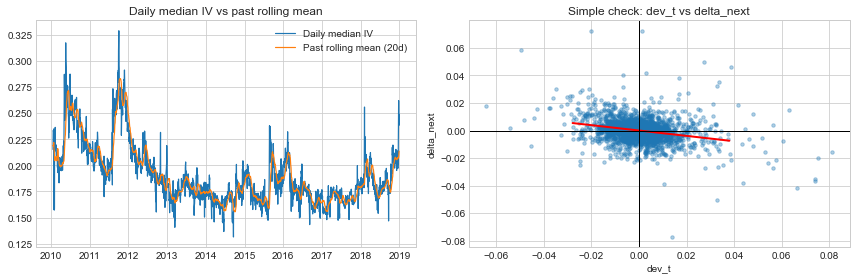

In [28]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) One simple daily IV series
simple = df[['date', 'iv']].copy()
simple['date'] = pd.to_datetime(simple['date'], errors='coerce')
simple['iv'] = pd.to_numeric(simple['iv'], errors='coerce')
simple = simple.dropna().groupby('date', as_index=False)['iv'].median().sort_values('date')

# 2) Past-only center and next-day change
simple['rolling_mean_20'] = simple['iv'].shift(1).rolling(20, min_periods=10).mean()
simple['dev_t'] = simple['iv'] - simple['rolling_mean_20']
simple['delta_next'] = simple['iv'].shift(-1) - simple['iv']

simple = simple.dropna(subset=['dev_t', 'delta_next']).copy()

# 3) One-line regression: delta_next = a + b * dev_t
X = np.column_stack([np.ones(len(simple)), simple['dev_t'].to_numpy()])
y = simple['delta_next'].to_numpy()
a, b = np.linalg.lstsq(X, y, rcond=None)[0]

print(f"Simple mean-reversion beta (b): {b:.6f}")
print("Interpretation: b < 0 supports mean reversion.")

# 4) Two easy visuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(simple['date'], simple['iv'], label='Daily median IV', linewidth=1.2)
axes[0].plot(simple['date'], simple['rolling_mean_20'], label='Past rolling mean (20d)', linewidth=1.2)
axes[0].set_title('Daily median IV vs past rolling mean')
axes[0].legend()

axes[1].scatter(simple['dev_t'], simple['delta_next'], s=12, alpha=0.35)
xline = np.linspace(simple['dev_t'].quantile(0.01), simple['dev_t'].quantile(0.99), 100)
axes[1].plot(xline, a + b * xline, color='red', linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Simple check: dev_t vs delta_next')
axes[1].set_xlabel('dev_t')
axes[1].set_ylabel('delta_next')

plt.tight_layout()
plt.show()
